
Aynı modelde başlangıç loss'unun neden çok yüksek olduğunu ve tanh'ın neden doyduğunu göster, videodaki histogramı çizdir. Kaiming init ile ağırlıkları ölçekle, iki sorunun da düzeldiğini göster.

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
%matplotlib inline


In [2]:

words = open('names.txt', 'r').read().splitlines()
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
block_size = 3

In [3]:


def build_dataset(words):  
  X, Y = [], []
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix]
  return torch.tensor(X), torch.tensor(Y)

random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
Xtr, Ytr = build_dataset(words[:n1])


Model başlangıçta her karaktere eşit olasılık ($1/27$) vermelidir: beklenen loss $-\ln(1/27) = 3.2958$.

In [4]:
print("beklenen loss baslangıç degeri", -torch.tensor(1/27.0).log().item())

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)

emb = C[Xtr[:32]]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr[:32])
print("naive loss başlangıç değeri:", loss.item())


W2_fixed = torch.randn((200, 27), generator=g) * 0.01
b2_fixed = torch.randn(27, generator=g) * 0
logits_fixed = h @ W2_fixed + b2_fixed
print("düzenlenmiş loss başlanıç değeri:", F.cross_entropy(logits_fixed, Ytr[:32]).item())

beklenen loss baslangıç degeri 3.295836925506592
naive loss başlangıç değeri: 24.41206932067871
düzenlenmiş loss başlanıç değeri: 3.2784526348114014


### tanh doygunluğu: çok fazla aykırı değerler -1 ve +1 değerleri almaya başlayıp gradyanı sıfırlayıp backwardın geri akışını engeller

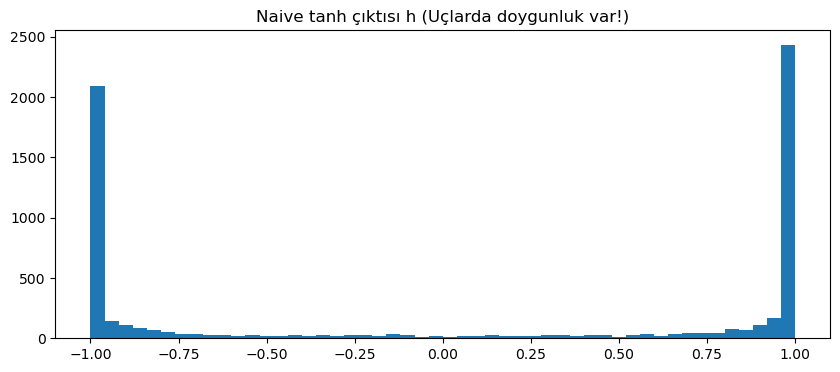

Doygun (|h| > 0.99) nöron oranı: % 60.9375


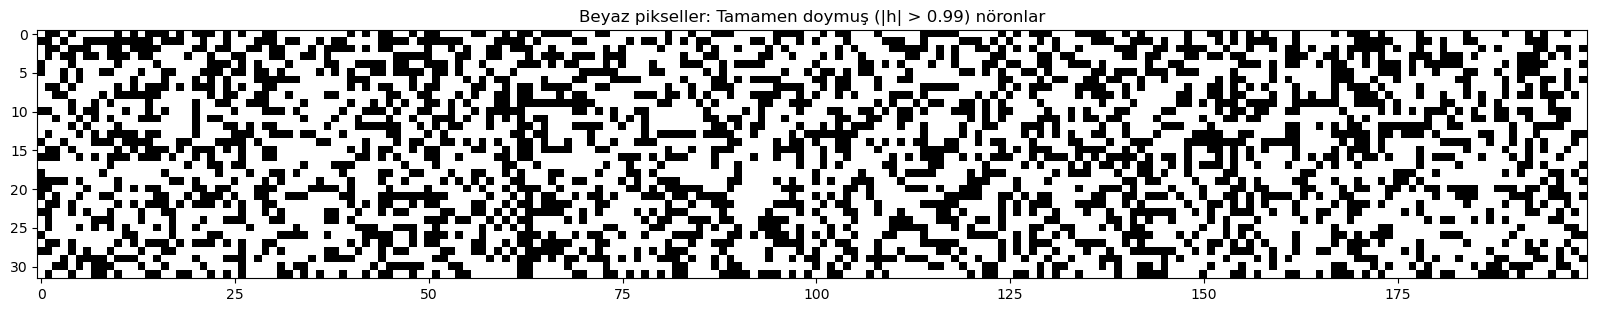

In [5]:

plt.figure(figsize=(10, 4))
plt.hist(h.view(-1).tolist(), 50)
plt.title("Naive tanh çıktısı h (Uçlarda doygunluk var!)")
plt.show()

print("Doygun (|h| > 0.99) nöron oranı: %", (h.abs() > 0.99).float().mean().item() * 100)

plt.figure(figsize=(20, 5))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')
plt.title("Beyaz pikseller: Tamamen doymuş (|h| > 0.99) nöronlar")
plt.show()

### Kaiming Normalizasyonu 

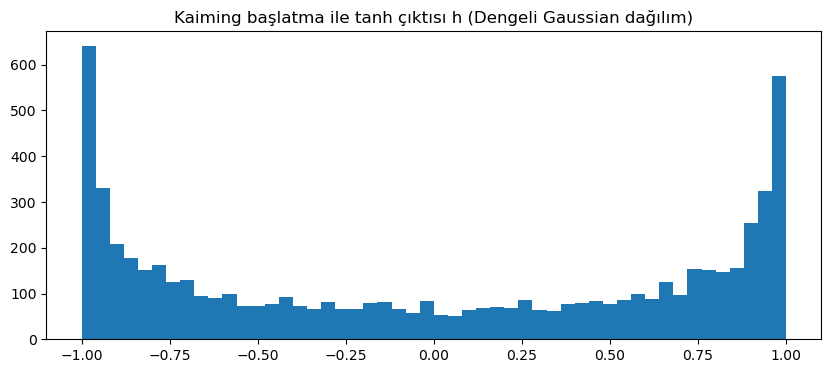

Kaiming sonrası doygun nöron oranı: % 7.656250149011612


In [6]:
n_embd = 10
n_hidden = 200
W1_kaiming = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5) # kaiming formülü ile ölçekleme
b1_kaiming = torch.randn(n_hidden, generator=g) * 0.01

h_kaiming = torch.tanh(emb.view(-1, 30) @ W1_kaiming + b1_kaiming)

plt.figure(figsize=(10, 4))
plt.hist(h_kaiming.view(-1).tolist(), 50)
plt.title("Kaiming başlatma ile tanh çıktısı h (Dengeli Gaussian dağılım)")
plt.show()

print("Kaiming sonrası doygun nöron oranı: %", (h_kaiming.abs() > 0.99).float().mean().item() * 100)